In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load NAV history
nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

# Compute daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("Shape:", nav.shape)
print("\nDaily Returns Sample:")
print(nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10))

# Validate distribution
print("\nDaily Returns Stats:")
print(nav['daily_return'].describe())

Shape: (46000, 4)

Daily Returns Sample:
      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073

Daily Returns Stats:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


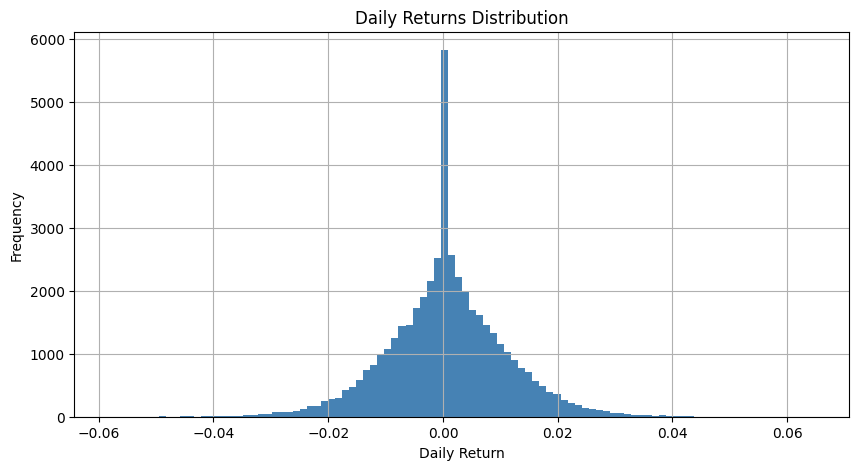

Chart saved!


In [2]:
# Plot distribution
plt.figure(figsize=(10,5))
nav['daily_return'].dropna().hist(bins=100, color='steelblue')
plt.title("Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.savefig("../reports/daily_returns_dist.png")
plt.show()
print("Chart saved!")

In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

def get_cagr(fund_df, years):
    end_date = fund_df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    filtered = fund_df[fund_df['date'] >= start_date]
    if len(filtered) < 2:
        return None
    start_nav = filtered['nav'].iloc[0]
    end_nav = filtered['nav'].iloc[-1]
    cagr = (end_nav / start_nav) ** (1/years) - 1
    return round(cagr * 100, 2)

results = []
for code, group in nav.groupby('amfi_code'):
    scheme = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = scheme[0] if len(scheme) > 0 else str(code)
    results.append({
        'scheme_name': name,
        'CAGR_1yr': get_cagr(group, 1),
        'CAGR_3yr': get_cagr(group, 3),
        'CAGR_5yr': get_cagr(group, 5)
    })

cagr_df = pd.DataFrame(results)
print(cagr_df.sort_values('CAGR_3yr', ascending=False).head(10))

                                          scheme_name  CAGR_1yr  CAGR_3yr  \
16                Axis Midcap Fund - Regular - Growth     22.26     35.11   
34      Mirae Asset Large Cap Fund - Regular - Growth     20.36     34.00   
24          ICICI Pru Bluechip Fund - Direct - Growth     13.06     32.49   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     53.23     32.44   
25           ICICI Pru Midcap Fund - Regular - Growth     29.60     31.78   
19          SBI Bluechip Fund - Regular Plan - Growth     60.44     30.46   
30             Kotak Flexicap Fund - Regular - Growth     26.66     29.58   
36      Mirae Asset Tax Saver Fund - Regular - Growth     39.75     29.18   
3       ABSL Frontline Equity Fund - Regular - Growth     47.92     28.97   
39              DSP Small Cap Fund - Regular - Growth     65.14     27.00   

    CAGR_5yr  
16     24.45  
34     26.80  
24     20.23  
2      26.07  
25     28.38  
19     22.38  
30     26.74  
36     27.63  
3      20.44  
39

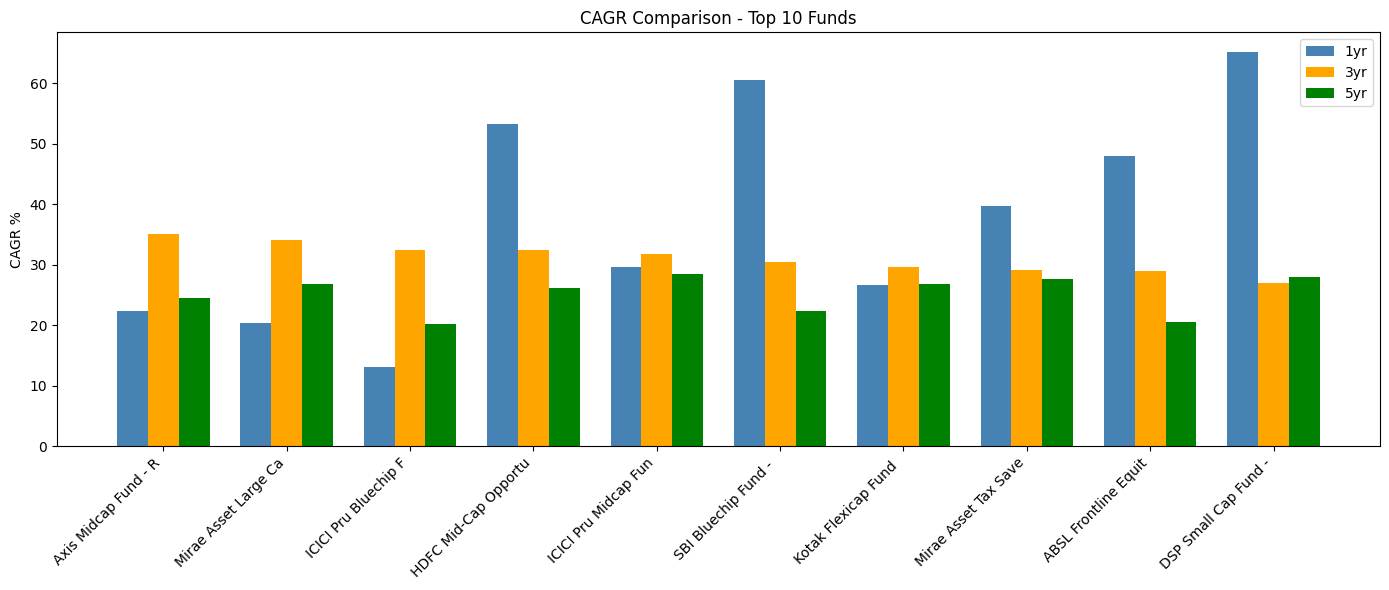

Chart saved!


In [4]:
import matplotlib.pyplot as plt

# Plot CAGR comparison
cagr_plot = cagr_df.sort_values('CAGR_3yr', ascending=False).head(10)

x = range(len(cagr_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(14,6))
ax.bar([i-width for i in x], cagr_plot['CAGR_1yr'], width, label='1yr', color='steelblue')
ax.bar([i for i in x], cagr_plot['CAGR_3yr'], width, label='3yr', color='orange')
ax.bar([i+width for i in x], cagr_plot['CAGR_5yr'], width, label='5yr', color='green')

ax.set_xticks(x)
ax.set_xticklabels([n[:20] for n in cagr_plot['scheme_name']], rotation=45, ha='right')
ax.set_title("CAGR Comparison - Top 10 Funds")
ax.set_ylabel("CAGR %")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/cagr_comparison.png")
plt.show()
print("Chart saved!")

##  Sharpe Ratio Analysis

Sharpe Ratio measures risk-adjusted return of each fund.

Formula: Sharpe = (Rp − Rf) / Std(Rp) × √252

- Higher Sharpe = Better fund performance per unit of risk
- Rf = 6.5% (RBI Repo Rate)
- Funds with Sharpe > 1 are considered good investments

In [6]:
import pandas as pd
import numpy as np

# Load data
nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

# Daily return calculate karo
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print("Ready!")
print(nav.columns.tolist())

Ready!
['amfi_code', 'date', 'nav', 'daily_return']


In [8]:
# Sharpe Ratio Calculation
risk_free_daily = 0.065 / 252

sharpe_results = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    
    mean_return = returns.mean()
    std_return = returns.std()
    
    sharpe = (mean_return - risk_free_daily) / std_return * np.sqrt(252)
    
    scheme = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = scheme[0] if len(scheme) > 0 else str(code)
    
    sharpe_results.append({
        'scheme_name': name,
        'sharpe_ratio': round(sharpe, 2),
        'avg_daily_return': round(mean_return * 100, 4),
        'volatility': round(std_return * 100, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results)
print(sharpe_df.sort_values('sharpe_ratio', ascending=False))

                                          scheme_name  sharpe_ratio  \
34      Mirae Asset Large Cap Fund - Regular - Growth          1.45   
30             Kotak Flexicap Fund - Regular - Growth          1.31   
36      Mirae Asset Tax Saver Fund - Regular - Growth          1.23   
19          SBI Bluechip Fund - Regular Plan - Growth          1.21   
25           ICICI Pru Midcap Fund - Regular - Growth          1.18   
38                 DSP Midcap Fund - Regular - Growth          1.13   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...          1.09   
9      Nippon India Large Cap Fund - Regular - Growth          1.08   
3       ABSL Frontline Equity Fund - Regular - Growth          1.03   
24          ICICI Pru Bluechip Fund - Direct - Growth          1.03   
16                Axis Midcap Fund - Regular - Growth          1.00   
39              DSP Small Cap Fund - Regular - Growth          0.95   
20           SBI Bluechip Fund - Direct Plan - Growth          0.95   
21    

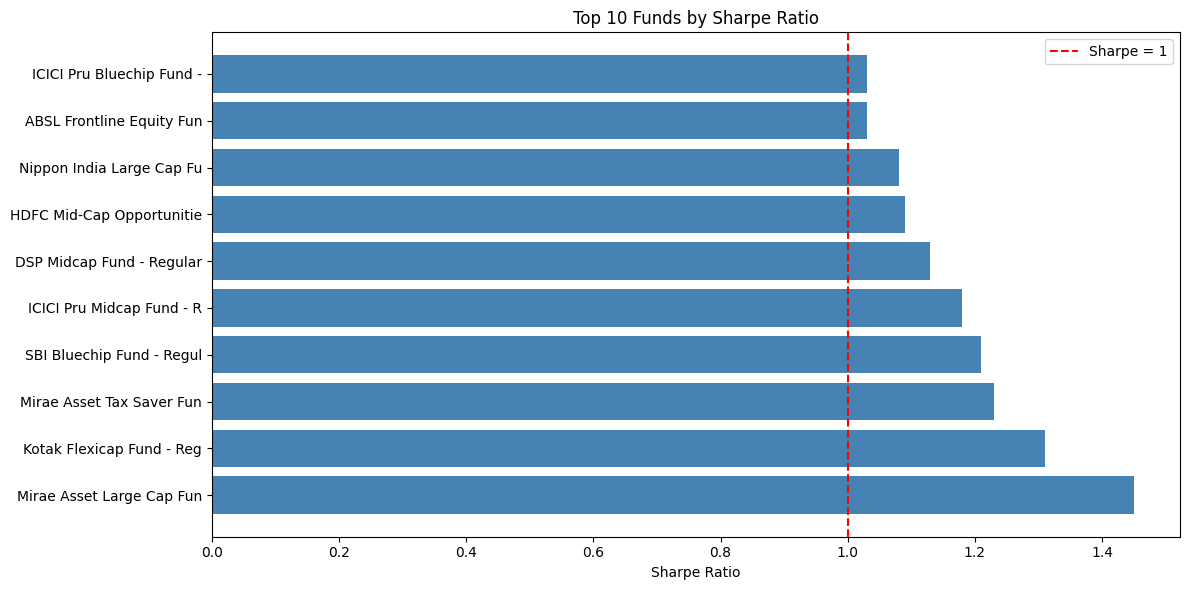

Chart saved!


In [9]:
import matplotlib.pyplot as plt

top10 = sharpe_df.sort_values('sharpe_ratio', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top10['scheme_name'].str[:25], top10['sharpe_ratio'], color='steelblue')
plt.xlabel("Sharpe Ratio")
plt.title("Top 10 Funds by Sharpe Ratio")
plt.axvline(x=1, color='red', linestyle='--', label='Sharpe = 1')
plt.legend()
plt.tight_layout()
plt.savefig("../reports/sharpe_ratio.png")
plt.show()
print("Chart saved!")

In [ ]:
# Rank all 40 funds by Sharpe Ratio
sharpe_ranked = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_ranked.index += 1  # start from rank 1

print("=== ALL 40 FUNDS RANKED BY SHARPE RATIO ===\n")
print(sharpe_ranked[['scheme_name', 'sharpe_ratio', 'volatility']].to_string())

=== ALL 40 FUNDS RANKED BY SHARPE RATIO ===

                                              scheme_name  sharpe_ratio  volatility
1           Mirae Asset Large Cap Fund - Regular - Growth          1.45      0.8941
2                  Kotak Flexicap Fund - Regular - Growth          1.31      1.0008
3           Mirae Asset Tax Saver Fund - Regular - Growth          1.23      1.1134
4               SBI Bluechip Fund - Regular Plan - Growth          1.21      0.8656
5                ICICI Pru Midcap Fund - Regular - Growth          1.18      1.2152
6                      DSP Midcap Fund - Regular - Growth          1.13      1.1179
7      HDFC Mid-Cap Opportunities Fund - Regular - Growth          1.09      1.1929
8          Nippon India Large Cap Fund - Regular - Growth          1.08      0.8913
9           ABSL Frontline Equity Fund - Regular - Growth          1.03      0.9177
10              ICICI Pru Bluechip Fund - Direct - Growth          1.03      0.9048
11                    Axis Midc

##  Sortino Ratio

Sortino Ratio measures risk-adjusted return using only downside risk (negative return days).

Formula: Sortino = (Rp − Rf) / Downside Std × √252

Higher Sortino = Fund handles losses better than peers.

In [ ]:
# Sortino Ratio Calculation
sortino_results = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    
    mean_return = returns.mean()
    
    # std of negative returns
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    
    if downside_std == 0:
        continue
    
    sortino = (mean_return - risk_free_daily) / downside_std * np.sqrt(252)
    
    scheme = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = scheme[0] if len(scheme) > 0 else str(code)
    
    sortino_results.append({
        'scheme_name': name,
        'sortino_ratio': round(sortino, 2)
    })

sortino_df = pd.DataFrame(sortino_results)
print(sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True))

                                          scheme_name  sortino_ratio
0       Mirae Asset Large Cap Fund - Regular - Growth           2.39
1              Kotak Flexicap Fund - Regular - Growth           2.36
2       Mirae Asset Tax Saver Fund - Regular - Growth           2.15
3           SBI Bluechip Fund - Regular Plan - Growth           2.14
4            ICICI Pru Midcap Fund - Regular - Growth           2.03
5                  DSP Midcap Fund - Regular - Growth           1.88
6      Nippon India Large Cap Fund - Regular - Growth           1.85
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...           1.83
8           ICICI Pru Bluechip Fund - Direct - Growth           1.81
9       ABSL Frontline Equity Fund - Regular - Growth           1.80
10                Axis Midcap Fund - Regular - Growth           1.70
11         SBI Small Cap Fund - Regular Plan - Growth           1.68
12  Mirae Asset Emerging Bluechip Fund - Regular -...           1.63
13              DSP Small Cap Fund

In [12]:
from scipy import stats

# Load benchmark data
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


##  Alpha and Beta Calculation

Alpha and Beta measure how a fund performs relative to the market (Nifty).

Beta = How much the fund moves when market moves
- Beta > 1 = Fund moves more than market (aggressive)
- Beta < 1 = Fund moves less than market (defensive)
- Beta = 1 = Fund moves exactly like market

Alpha = Extra return generated by fund manager
- Alpha > 0 = Fund beats the market 
- Alpha < 0 = Fund underperforms market 

Method:OLS Regression using scipy.stats.linregress

In [13]:
from scipy import stats

# Filter Nifty 100 benchmark
nifty = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()

# If NIFTY100 not found, use NIFTY50
if len(nifty) == 0:
    nifty = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
    print("Using NIFTY50 as benchmark")

nifty['date'] = pd.to_datetime(nifty['date'])
nifty = nifty.sort_values('date')
nifty['market_return'] = nifty['close_value'].pct_change()
nifty = nifty.dropna()

print("Benchmark shape:", nifty.shape)
print(nifty.head())

Benchmark shape: (1149, 4)
           date index_name  close_value  market_return
1151 2022-01-04   NIFTY100     17537.52      -0.013540
1152 2022-01-05   NIFTY100     17607.73       0.004003
1153 2022-01-06   NIFTY100     17556.05      -0.002935
1154 2022-01-07   NIFTY100     17664.02       0.006150
1155 2022-01-10   NIFTY100     17516.51      -0.008351


In [14]:
# Alpha and Beta calculation for all funds
alpha_beta_results = []

for code, group in nav.groupby('amfi_code'):
    fund_returns = group[['date', 'daily_return']].dropna()
    
    # Merge with benchmark
    merged = pd.merge(fund_returns, nifty[['date', 'market_return']], on='date')
    
    if len(merged) < 30:
        continue
    
    # OLS Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['market_return'], 
        merged['daily_return']
    )
    
    beta = round(slope, 4)
    alpha = round(intercept * 252, 4)  # Annualized
    
    scheme = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = scheme[0] if len(scheme) > 0 else str(code)
    
    alpha_beta_results.append({
        'scheme_name': name,
        'alpha': alpha,
        'beta': beta,
        'r_squared': round(r_value**2, 4)
    })

ab_df = pd.DataFrame(alpha_beta_results)
print(ab_df.sort_values('alpha', ascending=False).reset_index(drop=True))

                                          scheme_name   alpha    beta  \
0          SBI Small Cap Fund - Regular Plan - Growth  0.3034 -0.0232   
1               DSP Small Cap Fund - Regular - Growth  0.3006  0.0115   
2            ICICI Pru Midcap Fund - Regular - Growth  0.2926  0.0005   
3       Mirae Asset Tax Saver Fund - Regular - Growth  0.2827  0.0181   
4              Kotak Flexicap Fund - Regular - Growth  0.2733 -0.0228   
5   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.2720  0.0051   
6       Mirae Asset Large Cap Fund - Regular - Growth  0.2698  0.0237   
7                  DSP Midcap Fund - Regular - Growth  0.2660 -0.0025   
8                 Axis Midcap Fund - Regular - Growth  0.2608 -0.0663   
9           SBI Bluechip Fund - Regular Plan - Growth  0.2320 -0.0318   
10     Nippon India Large Cap Fund - Regular - Growth  0.2183 -0.0084   
11      ABSL Frontline Equity Fund - Regular - Growth  0.2140  0.0211   
12          ICICI Pru Bluechip Fund - Direct - Grow

## Maximum Drawdown

Maximum Drawdown measures the largest peak-to-trough decline in a fund's NAV.

Formula: Max Drawdown = min(NAV / Running Max − 1)

- Running Max = Highest NAV achieved so far
- Drawdown = How much NAV fell from its peak

Interpretation:
- Lower drawdown = Fund is safer during market crashes
- Higher drawdown = Fund fell more during bad times

Use case: Helps investors understand worst case loss scenario.

In [15]:
# Maximum Drawdown Calculation
drawdown_results = []

for code, group in nav.groupby('amfi_code'):
    fund_data = group.sort_values('date').copy()
    
    # Running maximum
    fund_data['running_max'] = fund_data['nav'].cummax()
    
    # Drawdown
    fund_data['drawdown'] = fund_data['nav'] / fund_data['running_max'] - 1
    
    # Maximum drawdown
    max_drawdown = fund_data['drawdown'].min()
    worst_date = fund_data.loc[fund_data['drawdown'].idxmin(), 'date']
    
    scheme = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = scheme[0] if len(scheme) > 0 else str(code)
    
    drawdown_results.append({
        'scheme_name': name,
        'max_drawdown_pct': round(max_drawdown * 100, 2),
        'worst_date': worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results)
print(drawdown_df.sort_values('max_drawdown_pct').reset_index(drop=True))

                                          scheme_name  max_drawdown_pct  \
0           SBI Small Cap Fund - Direct Plan - Growth            -52.57   
1              Axis Small Cap Fund - Regular - Growth            -51.68   
2              ABSL Small Cap Fund - Regular - Growth            -35.45   
3               DSP Small Cap Fund - Regular - Growth            -31.17   
4          SBI Small Cap Fund - Regular Plan - Growth            -28.71   
5                 UTI Mid Cap Fund - Regular - Growth            -28.00   
6           HDFC Top 100 Fund - Regular Plan - Growth            -24.73   
7       Kotak Emerging Equity Fund - Regular - Growth            -24.00   
8      Nippon India Small Cap Fund - Regular - Growth            -23.34   
9                Axis Bluechip Fund - Direct - Growth            -21.75   
10              UTI Flexi Cap Fund - Regular - Growth            -21.54   
11  HDFC Mid-Cap Opportunities Fund - Direct - Growth            -21.12   
12                Axis Mi

##  Fund Scorecard (0-100)

A composite score to rank all funds across multiple performance metrics.

Weightage:
| Metric | Weight | Why |
|--------|--------|-----|
| 3yr CAGR Return | 30% | Long term return is most important |
| Sharpe Ratio | 25% | Measures risk adjusted return |
| Alpha | 20% | Shows fund manager skill |
| Expense Ratio | 15% | Lower fee is better (inverse rank) |
| Max Drawdown | 10% | Lower loss is better (inverse rank) |

Inverse Rank: For Expense Ratio and Max Drawdown,
lower value = better rank.

Score Range: 0 to 100 — Higher score = Better fund overall.

### Fund Scorecard Analysis

Mid-cap and flexi-cap funds achieved the highest composite scores due to strong 3-year returns, higher Sharpe ratios, and positive alpha generation. Large-cap and index funds showed moderate performance, while liquid and gilt funds ranked lower because of their lower return potential despite having lower risk and drawdowns.

In [16]:
import pandas as pd
import numpy as np

# Collect all metrics
scorecard = pd.DataFrame()
scorecard['scheme_name'] = cagr_df['scheme_name']
scorecard['cagr_3yr'] = cagr_df['CAGR_3yr']
scorecard['sharpe'] = sharpe_df['sharpe_ratio'].values
scorecard['alpha'] = ab_df['alpha'].values
scorecard['expense_ratio'] = pd.read_csv("../data/raw/07_scheme_performance.csv")['expense_ratio_pct'].values[:len(scorecard)]
scorecard['max_drawdown'] = drawdown_df['max_drawdown_pct'].values[:len(scorecard)]

# Rank each metric
scorecard['rank_cagr'] = scorecard['cagr_3yr'].rank(ascending=True)
scorecard['rank_sharpe'] = scorecard['sharpe'].rank(ascending=True)
scorecard['rank_alpha'] = scorecard['alpha'].rank(ascending=True)
scorecard['rank_expense'] = scorecard['expense_ratio'].rank(ascending=False)  # Inverse
scorecard['rank_dd'] = scorecard['max_drawdown'].rank(ascending=False)  # Inverse

# Normalize ranks 0-100
n = len(scorecard)
for col in ['rank_cagr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_dd']:
    scorecard[col] = (scorecard[col] / n) * 100

# Composite Score
scorecard['score'] = (
    0.30 * scorecard['rank_cagr'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_dd']
)

scorecard['score'] = scorecard['score'].round(2)
print(scorecard[['scheme_name', 'score']].sort_values('score', ascending=False).reset_index(drop=True))

                                          scheme_name  score
0            ICICI Pru Midcap Fund - Regular - Growth  87.12
1                 Axis Midcap Fund - Regular - Growth  85.06
2           SBI Bluechip Fund - Regular Plan - Growth  84.12
3              Kotak Flexicap Fund - Regular - Growth  82.38
4       Mirae Asset Large Cap Fund - Regular - Growth  80.00
5   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  79.00
6      Nippon India Large Cap Fund - Regular - Growth  76.25
7               DSP Small Cap Fund - Regular - Growth  74.94
8       Mirae Asset Tax Saver Fund - Regular - Growth  73.94
9       ABSL Frontline Equity Fund - Regular - Growth  73.75
10         SBI Small Cap Fund - Regular Plan - Growth  71.25
11                 DSP Midcap Fund - Regular - Growth  67.50
12          ICICI Pru Bluechip Fund - Direct - Growth  65.75
13              UTI Flexi Cap Fund - Regular - Growth  62.00
14         ICICI Pru Bluechip Fund - Regular - Growth  56.75
15      Nippon India Lar

In [21]:
%whos DataFrame

Variable        Type         Data/Info
--------------------------------------
ab_df           DataFrame    Shape: (40, 4)
benchmark       DataFrame    Shape: (8050, 3)
cagr_df         DataFrame    Shape: (40, 4)
cagr_plot       DataFrame    Shape: (10, 4)
drawdown_df     DataFrame    Shape: (40, 3)
fund_data       DataFrame    Shape: (1150, 6)
fund_master     DataFrame    Shape: (40, 15)
fund_returns    DataFrame    Shape: (1149, 2)
group           DataFrame    Shape: (1150, 4)
merged          DataFrame    Shape: (1149, 3)
nav             DataFrame    Shape: (46000, 4)
nifty           DataFrame    Shape: (1149, 4)
scorecard       DataFrame    Shape: (40, 12)
sharpe_df       DataFrame    Shape: (40, 4)
sharpe_ranked   DataFrame    Shape: (40, 4)
sortino_df      DataFrame    Shape: (40, 2)
top10           DataFrame    Shape: (10, 4)


In [22]:
print(nav.columns)
print(benchmark.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')


In [23]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [24]:
nav_plot = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_plot.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [25]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [26]:
top5_funds = (
    scorecard
    .sort_values('score', ascending=False)
    .head(5)['scheme_name']
    .tolist()
)

print(top5_funds)

['ICICI Pru Midcap Fund - Regular - Growth', 'Axis Midcap Fund - Regular - Growth', 'SBI Bluechip Fund - Regular Plan - Growth', 'Kotak Flexicap Fund - Regular - Growth', 'Mirae Asset Large Cap Fund - Regular - Growth']


In [27]:
nav_plot['date'] = pd.to_datetime(nav_plot['date'])

latest_date = nav_plot['date'].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3yr = nav_plot[
    nav_plot['date'] >= start_date
].copy()

In [28]:
plot_data = []

for fund in top5_funds:

    temp = nav_3yr[
        nav_3yr['scheme_name'] == fund
    ].copy()

    temp['normalized_nav'] = (
        temp['nav'] /
        temp['nav'].iloc[0]
    ) * 100

    plot_data.append(temp)

plot_data = pd.concat(plot_data)

In [29]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark_3yr = benchmark[
    benchmark['date'] >= start_date
].copy()

nifty50 = benchmark_3yr[
    benchmark_3yr['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark_3yr[
    benchmark_3yr['index_name'] == 'NIFTY100'
].copy()

In [30]:
nifty50['normalized_nav'] = (
    nifty50['close_value']
    /
    nifty50['close_value'].iloc[0]
) * 100

nifty100['normalized_nav'] = (
    nifty100['close_value']
    /
    nifty100['close_value'].iloc[0]
) * 100

### Benchmark Comparison Analysis

The top-ranked funds consistently outperformed both Nifty 50 and Nifty 100 over the last three years. Mid-cap and flexi-cap funds generated stronger cumulative growth, while benchmark indices exhibited comparatively stable performance. Tracking error analysis showed varying degrees of deviation from benchmark returns, indicating differences in active management strategies across funds.

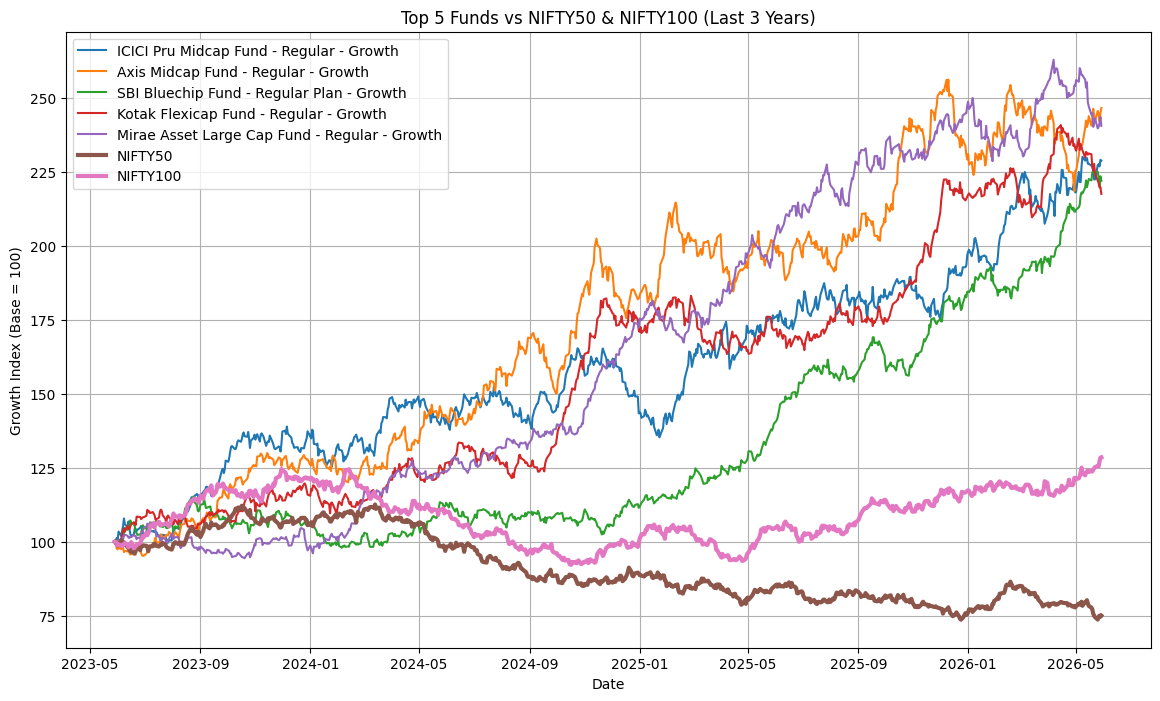

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5_funds:

    temp = plot_data[
        plot_data['scheme_name'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['normalized_nav'],
        label=fund
    )

plt.plot(
    nifty50['date'],
    nifty50['normalized_nav'],
    linewidth=3,
    label='NIFTY50'
)

plt.plot(
    nifty100['date'],
    nifty100['normalized_nav'],
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    'Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)'
)

plt.xlabel('Date')
plt.ylabel('Growth Index (Base = 100)')
plt.legend()
plt.grid(True)

plt.savefig(
    '../reports/benchmark_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [32]:
import numpy as np

tracking_errors = []

nifty100_ret = nifty100.copy()

nifty100_ret['benchmark_return'] = (
    nifty100_ret['close_value']
    .pct_change()
)

In [35]:
for fund in top5_funds:

    fund_ret = nav_plot[
        nav_plot['scheme_name'] == fund
    ][['date','daily_return']]

    merged = fund_ret.merge(
        nifty100_ret[
            ['date','benchmark_return']
        ],
        on='date'
    )

    print(fund)
    print("Fund rows:", len(fund_ret))
    print("Merged rows:", len(merged))
    print("-" * 50)

ICICI Pru Midcap Fund - Regular - Growth
Fund rows: 1150
Merged rows: 785
--------------------------------------------------
Axis Midcap Fund - Regular - Growth
Fund rows: 1150
Merged rows: 785
--------------------------------------------------
SBI Bluechip Fund - Regular Plan - Growth
Fund rows: 1150
Merged rows: 785
--------------------------------------------------
Kotak Flexicap Fund - Regular - Growth
Fund rows: 1150
Merged rows: 785
--------------------------------------------------
Mirae Asset Large Cap Fund - Regular - Growth
Fund rows: 1150
Merged rows: 785
--------------------------------------------------


In [37]:
tracking_errors = []

for fund in top5_funds:

    fund_ret = nav_plot[
        nav_plot['scheme_name'] == fund
    ][['date', 'daily_return']]

    merged = fund_ret.merge(
        nifty100_ret[
            ['date', 'benchmark_return']
        ],
        on='date'
    )

    merged = merged.dropna()

    te = (
        (
            merged['daily_return']
            - merged['benchmark_return']
        ).std()
    ) * np.sqrt(252)

    tracking_errors.append(
        [fund, round(te, 4)]
    )

In [38]:
tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        'scheme_name',
        'tracking_error'
    ]
)

tracking_error_df = tracking_error_df.sort_values(
    'tracking_error'
)

tracking_error_df

,scheme_name,tracking_error
4,Mirae Asset Large Cap Fund - Regular - Growth,0.1880
2,SBI Bluechip Fund - Regular Plan - Growth,0.1936
3,Kotak Flexicap Fund - Regular - Growth,0.2065
0,ICICI Pru Midcap Fund - Regular - Growth,0.2327
1,Axis Midcap Fund - Regular - Growth,0.2398


### Tracking Error Analysis

Tracking error measures how closely a fund's returns follow its benchmark. Mirae Asset Large Cap Fund recorded the lowest tracking error, indicating the closest alignment with NIFTY100 performance. In contrast, Axis Midcap Fund exhibited the highest tracking error, reflecting greater deviation from benchmark returns and a more active management approach.

In [39]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [40]:
ab_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [41]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'aum_growth.png',
 'benchmark_comparison.png',
 'cagr_comparison.png',
 'category_wise_net_inflow.png',
 'correlation_matrix.png',
 'daily_returns_dist.png',
 'fund_scorecard.csv',
 'gender_avg_sip.png',
 'gender_distribution.png',
 'Investor_Distribution_by_age.png',
 'Monthly_SIP_Inflow.png',
 'mutual_fund_folio.png',
 'payment_mode_distribution.png',
 'Sector_allocation.png',
 'sharpe_ratio.png',
 'SIP_amount_distribution.png',
 'tier_distribution.png',
 'top10_fundhouses.png',
 'Total_sip.png']